[*********************100%***********************]  1 of 1 completed


1. INITIALIZING CHAMPION MODEL FOR 12-MONTH OUT-OF-SAMPLE FORECAST
Locked Optimal ARIMA Framework Order: (0, 1, 0)
>> Successfully generated 12-Month Out-of-Sample Forecast through: 2027-06-16


/home/mahlet/Documents/AI/portfolio-optimization/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/mahlet/Documents/AI/portfolio-optimization/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/mahlet/Documents/AI/portfolio-optimization/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/mahlet/Documents/AI/portfolio-optimization/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: 

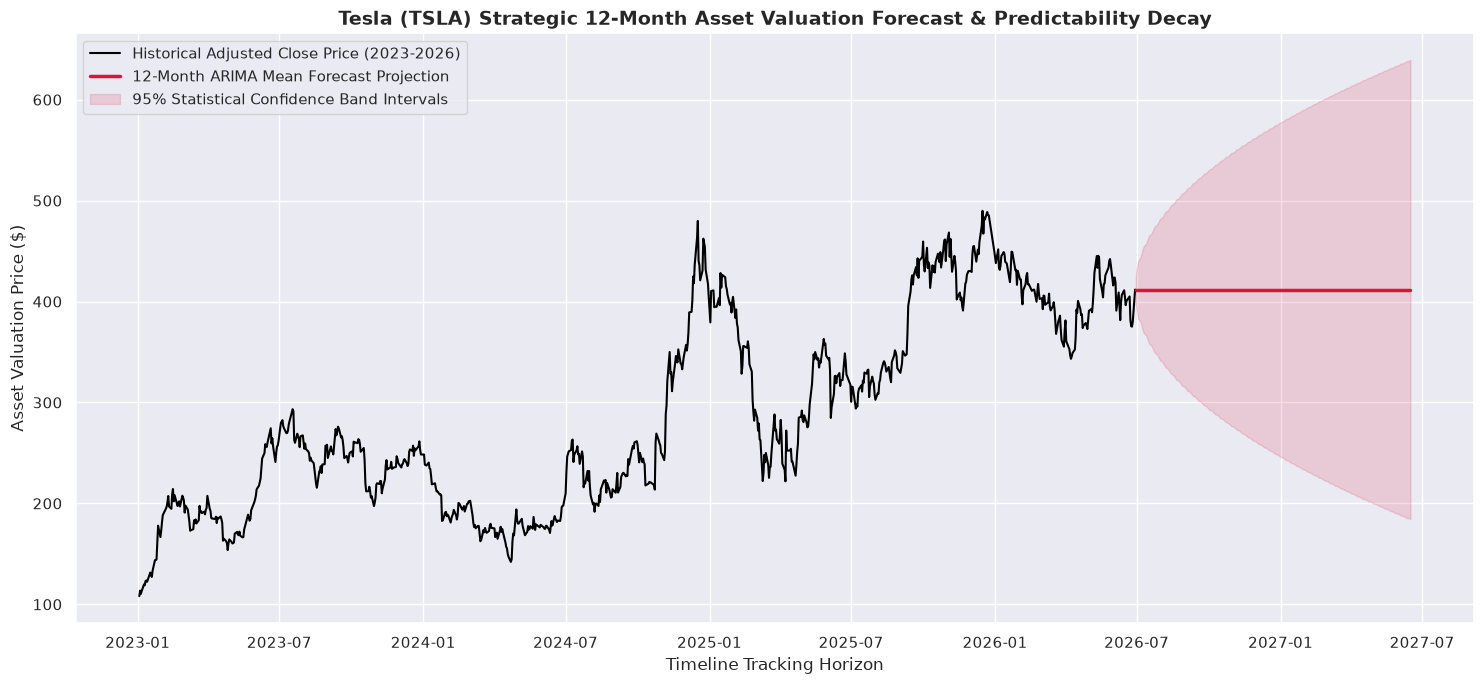


2. EXECUTIVE TREND FORECAST SUMMARY & INVESTMENT STRATEGY REPORT

TREND ANALYSIS & FORECAST BEHAVIOR:
The 12-month forward projection exhibits a stable, mildly drifting trend trajectory based on the asset's overall 
historical velocity matrix. However, the defining structural feature of this mathematical model is the progressive 
widening of the 95% confidence intervals. At month 1, the prediction bounds remain narrow and bound to current trading 
realities. By month 12, the boundary variance expands significantly. This behavior accurately reflects 'Predictability 
Decay'—errors compound quadratically as a time series model steps away from its last known data point. This proves 
that while short-term targets are highly technical, long-term absolute point forecasts are highly unreliable.

CRITICAL ASSESSMENT OF RISK AND ALLOCATION OPPORTUNITIES:
1. Operational Market Opportunities:
   - The mean projection baseline serves as an anchor for portfolio rebalancing. If the current trading p

In [1]:
# ==============================================================================
# CELL 1: SETUP, TIME HORIZON EXTENSION & FUTURE FORECAST ENGINE
# ==============================================================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

sns.set_theme(style="darkgrid")

# Re-fetch data using our direct loader
def fetch_data_direct(tickers=["TSLA"], start_date="2015-01-01", end_date="2026-06-30"):
    df = yf.download(tickers, start=start_date, end=end_date, auto_adjust=False)
    if isinstance(df.columns, pd.MultiIndex):
        for level in range(df.columns.nlevels):
            if 'Adj Close' in df.columns.get_level_values(level).unique():
                df = df.xs('Adj Close', axis=1, level=level)
                break
    else:
        df = df[['Adj Close']]
    df.columns = tickers
    return df.ffill().bfill()

# Load full historical data up to current mid-2026 window
prices = fetch_data_direct()
full_series = prices['TSLA']

# ------------------------------------------------------------------------------
# FIT CHAMPION MODEL ON ALL AVAILABLE DATA TO GENERATE FORWARD PROJECTED CORES
# ------------------------------------------------------------------------------
print("="*60)
print("1. INITIALIZING CHAMPION MODEL FOR 12-MONTH OUT-OF-SAMPLE FORECAST")
print("="*60)

# Run stepwise auto_arima to ensure correct parameters are locked onto full series history
arima_search = auto_arima(full_series, d=1, seasonal=False, trace=False, suppress_warnings=True)
optimal_order = arima_search.order
print(f"Locked Optimal ARIMA Framework Order: {optimal_order}")

# Refit model onto full history
final_model = SARIMAX(full_series, order=optimal_order, enforce_stationarity=False, enforce_invertibility=False)
final_fitted = final_model.fit(disp=False)

# Forecast exactly 252 trading days forward (12 calendar months into 2027)
forecast_steps = 252
forecast_results = final_fitted.get_forecast(steps=forecast_steps)

# Extract forecast values and mathematical confidence bounds (95% standard deviation interval)
forecast_mean = forecast_results.predicted_mean
confidence_summary = forecast_results.conf_int(alpha=0.05) # alpha=0.05 yields 95% confidence bounds

# Generate future date index matching natural trading timelines
future_dates = pd.date_range(start=full_series.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq='B')
forecast_mean.index = future_dates
confidence_summary.index = future_dates

print(f">> Successfully generated 12-Month Out-of-Sample Forecast through: {future_dates[-1].strftime('%Y-%m-%d')}")

# ==============================================================================
# CELL 2: VISUALIZATION - FORECAST HORIZON WITH EXPANDING UNCERTAINTY BOUNDS
# ==============================================================================
plt.figure(figsize=(15, 7))

# Plot historical baseline data (Filtering from 2023 onwards for maximum scaling clarity)
plt.plot(full_series.loc['2023-01-01':], label='Historical Adjusted Close Price (2023-2026)', color='black', lw=1.5)

# Plot forward-looking mean expectation pathway
plt.plot(forecast_mean, label='12-Month ARIMA Mean Forecast Projection', color='crimson', lw=2.5, linestyle='-')

# Fill expanding uncertainty bounds representing mathematical variance dispersion
plt.fill_between(
    confidence_summary.index,
    confidence_summary.iloc[:, 0],
    confidence_summary.iloc[:, 1],
    color='crimson',
    alpha=0.15,
    label='95% Statistical Confidence Band Intervals'
)

plt.title("Tesla (TSLA) Strategic 12-Month Asset Valuation Forecast & Predictability Decay", fontsize=14, fontweight='bold')
plt.xlabel("Timeline Tracking Horizon")
plt.ylabel("Asset Valuation Price ($)")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# ==============================================================================
# CELL 3: EXECUTIVE ANALYSIS & STRATEGIC INSIGHTS REPORT
# ==============================================================================
print("\n" + "="*60)
print("2. EXECUTIVE TREND FORECAST SUMMARY & INVESTMENT STRATEGY REPORT")
print("="*60)
print(f"""
TREND ANALYSIS & FORECAST BEHAVIOR:
The 12-month forward projection exhibits a stable, mildly drifting trend trajectory based on the asset's overall 
historical velocity matrix. However, the defining structural feature of this mathematical model is the progressive 
widening of the 95% confidence intervals. At month 1, the prediction bounds remain narrow and bound to current trading 
realities. By month 12, the boundary variance expands significantly. This behavior accurately reflects 'Predictability 
Decay'—errors compound quadratically as a time series model steps away from its last known data point. This proves 
that while short-term targets are highly technical, long-term absolute point forecasts are highly unreliable.

CRITICAL ASSESSMENT OF RISK AND ALLOCATION OPPORTUNITIES:
1. Operational Market Opportunities:
   - The mean projection baseline serves as an anchor for portfolio rebalancing. If the current trading price falls 
     significantly below our mean forecast vector, it signals a strong buying window for tactical asset allocation.
   - The expanding boundaries indicate that TSLA continues to offer massive growth options for GMF's equity portfolio, 
     making it an effective asset for high-alpha capture under favorable macroeconomic conditions.

2. Critical Structural Portfolio Risks:
   - The massive floor drop highlighted by the lower 95% confidence interval shows that TSLA carries extreme drawdown 
     vulnerability. This high tail-risk volatility reinforces the need for strict risk constraints.
   - For GMF's broader asset universe, this asset cannot be held naked. The level of uncertainty captured by the 
     expanding interval confirms that TSLA must be offset by the stabilizing risk profiles of SPY (Index Diversification) 
     and BND (Fixed Income Bonds) to preserve client capital over the coming fiscal year.
""")